In [1]:
import pandas as pd

df = pd.read_csv("data/lending_club_preprocessed.csv", parse_dates=['issue_d', 'earliest_cr_line'])


C:\Users\user\AppData\Local\Temp\ipykernel_10652\1692897667.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("data/lending_club_preprocessed.csv", parse_dates=['issue_d', 'earliest_cr_line'])


In [2]:
# 필요 라이브러리 로드
import numpy as np

In [3]:
# 모델을 위해 최적화된 변수 선택 
use_col = [
    # ── 타겟 ──
    "target",                        # 부도 여부 (0/1)
    # ── 대출 기본 정보 ──
    "loan_amnt",                     # 대출 금액
    "term",                          # 기간 (36/60개월)
    "int_rate",                      # 이자율
    "sub_grade",                     # 등급 세분류 (A1~G5)
    "installment",                   # 월 상환액 ($)
    "purpose",                       # 대출 목적
    "issue_year",                    # 대출 실행 연도
    # ── 차입자 정보 ──
    "emp_length",                    # 근속 연수
    "home_ownership",                # 주거 형태
    "annual_inc",                    # 자기보고 연소득 ($)
    # ── 부채 관련 지표 ──
    "dti",                           # 부채 대비 소득 비율
    "fico_mid",                      # FICO 점수 평균
    "pub_rec",                       # 공공 부정 기록 건수
    # ── 계좌 잔액 / 한도 ──
    "avg_cur_bal",                   # 전체 계좌 평균 잔액 ($)
    "revol_bal",                     # 리볼빙 총 잔액 ($)
    "revol_util",                    # 리볼빙 이용률 (%)
    "total_rev_hi_lim",              # 전체 리볼빙 신용 한도 ($)
    "bc_open_to_buy",                # 뱅크카드 잔여 한도 ($)
    "total_bc_limit",                # 뱅크카드 총 한도 ($)
    "tot_hi_cred_lim",               # 전체 계좌 신용한도 합계 ($)
    # ── 계좌 수량 ──
    "num_actv_bc_tl",                # 활성 뱅크카드 수
    "num_actv_rev_tl",               # 활성 리볼빙 계좌 수
    "num_rev_tl_bal_gt_0",           # 잔액 > 0인 리볼빙 계좌 수
    "num_il_tl",                     # 할부 계좌 수
    "total_acc",                     # 전체 신용 계좌 수
    "acc_open_past_24mths",          # 최근 24개월 신규 계좌 수
    # ── 계좌 경과 기간 ──
    "mo_sin_old_rev_tl_op",          # 가장 오래된 리볼빙 계좌 경과 월수
    "mo_sin_rcnt_rev_tl_op",         # 가장 최근 리볼빙 계좌 경과 월수
    "mo_sin_old_il_acct",            # 가장 오래된 할부 계좌 경과 월수
    "mths_since_recent_bc",          # 최근 뱅크카드 개설 경과 월수
    "mths_since_recent_inq",         # 최근 신용 조회 경과 월수
    "mths_since_rcnt_il",            # 최근 할부 계좌 경과 월수 
    # ── 연체 경과 (mths_since 계열) ──
    "mths_since_last_delinq",        # 마지막 연체 경과 월수 
    "mths_since_last_major_derog",   # 마지막 주요 부정 기록 경과 월수 
    "mths_since_recent_revol_delinq",# 최근 리볼빙 연체 경과 월수
    "mths_since_recent_bc_dlq",      # 최근 뱅크카드 연체 경과 월수 
    # ── 연체 이력 지표 ──
    "pct_tl_nvr_dlq",                # 연체 없는 계좌 비율 (%)
    # ── 파생 플래그 ──
    "mths_since_last_major_derog_flag", #  마지막 주요 부정 기록 경과 (Y/N)1 
    "mths_since_recent_inq_flag" ,  # 가장 최근 신용 조회 이후 경과 월수 (Y/N)1
    "issue_d", "earliest_cr_line"
]

df = df[use_col]


In [4]:
# 파생컬럼 
df['issue_year'] = df['issue_d'].dt.year.astype(str)
df['issue_month'] = df['issue_d'].dt.month.astype(str) 
df["earliest_cr_line_year"]= pd.to_datetime(df["earliest_cr_line"]).dt.year.astype(str)

df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12) # installment_to_income (월상환부담률)
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'] #  loan_to_income (대출규모 대비 소득)
df['revol_bal_to_income'] = df['revol_bal'] / df['annual_inc'] #  revol_bal_to_income (회전부채 대비 소득)

#숫자 잘못 처리 되었을 때 NaN 처리
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
for col in new_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# 생성후 Drop / "annual_inc", "revol_bal","installment" 은 개인 판단으로 고고 저는 뺄예정 
df = df.drop(columns=["issue_d", "earliest_cr_line", "annual_inc", "revol_bal","installment"])



print(f"전체: {len(df.columns)}")
print(f"고유: {len(set(df.columns))}")

전체: 42
고유: 42


# split하고 진행


In [5]:
from sklearn.model_selection import train_test_split

# 공통 전처리 완료 df

target_col = "target"

# 1) split 먼저
X = df.drop(columns=[target_col]).copy() 
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
 # 파생변수 결측값 채우기(★train/test 이후 결측값 채우기)
 new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income',]
 for col in new_cols:
     train_median = X_train[col].median()                    # train으로만 계산
     X_train[col] = X_train[col].fillna(train_median)       # train에 적용
     X_test[col] = X_test[col].fillna(train_median)         # test에도 train median 사용

In [7]:
## mo_sin_old_il_acct  가장 오래된 할부 계좌 이후 경과 월수
## 0 으로 
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(0) 
X_test["mo_sin_old_il_acct"] =  X_test["mo_sin_old_il_acct"].fillna(0) 


# mths_since_rcnt_il 가장 최근 할부 계좌(Installment Loan) 개설 이후 경과 월수
## 중앙값으로 채우기 
medi_rcnt_il = X_train["mths_since_rcnt_il"].median()
X_train["mths_since_rcnt_il"] = X_train["mths_since_rcnt_il"].fillna(medi_rcnt_il)
X_test["mths_since_rcnt_il"] = X_test["mths_since_rcnt_il"].fillna(medi_rcnt_il)


In [8]:
# ★train/test 이후 전처리
# dti "sub_grade" 사용해야함 
X_train["dti"] = X_train.groupby("sub_grade")["dti"].transform(lambda x: x.fillna(x.median())
)
train_dit_medi = X_train.groupby("sub_grade")["dti"].median()
X_test["dti"] = X_test["dti"].fillna(X_test["sub_grade"].map(train_dit_medi))

# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_bc'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1)
    X_test[col] = X_test[col].fillna(max_val + 1)
    
# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

In [9]:
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())
print(X_test.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0
0
0


In [14]:
# =========================
# XGBoost + class weight + GridSearchCV
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, make_scorer, f1_score
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# 1) 컬럼 타입 분리
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# 2) 전처리 (XGBoost는 스케일링 불필요)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# 3) 클래스 가중치(scale_pos_weight)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

# 4) 파이프라인
xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        scale_pos_weight=scale_pos_weight
    ))
])

# 5) GridSearchCV (대규모 그리드)
param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}


scorer = make_scorer(f1_score, pos_label=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=1,
    verbose=3
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV f1(1):", grid.best_score_)


scale_pos_weight: 3.9474827943354405
Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV 1/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.441 total time=  17.0s
[CV 2/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.439 total time=  17.7s
[CV 3/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.440 total time=  18.8s
[CV 4/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.440 total time=  16.7s
[CV 5/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.440 total time=  16.9s
[CV 1/5] END model__colsample_bytree=0.8, model__learning_rat

In [11]:
# cuda 사용 버전!!!!!!!!!!!!!

# =========================
# XGBoost + class weight + GridSearchCV
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, make_scorer, f1_score
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# 1) 컬럼 타입 분리
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# 2) 전처리 (XGBoost는 스케일링 불필요)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# 3) 클래스 가중치(scale_pos_weight)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

# 4) 파이프라인
xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
        device="cuda",
        scale_pos_weight=scale_pos_weight
    ))
])

# 5) GridSearchCV (대규모 그리드)
param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}



scorer = make_scorer(f1_score, pos_label=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=1,
    verbose=3
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV f1(1):", grid.best_score_)


scale_pos_weight: 3.9474827943354405
Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [17:51:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV 1/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.442 total time=  12.1s
[CV 2/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.439 total time=  11.0s
[CV 3/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.440 total time=  11.0s
[CV 4/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.441 total time=  11.3s
[CV 5/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=0.8;, score=0.440 total time=  11.1s
[CV 1/5] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=200, model__subsample=1.0;, score=0.442 total time=

In [15]:
# CPU, GPU 최적 파라미터 성능 보기
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# 공통 클래스 가중치
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# 1) CPU best params 모델
cpu_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        device="cpu",
        scale_pos_weight=scale_pos_weight,
        colsample_bytree=0.8,
        learning_rate=0.1,
        max_depth=5,
        n_estimators=600,
        subsample=0.8
    ))
])

# 2) GPU best params 모델
gpu_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        device="cuda",
        scale_pos_weight=scale_pos_weight,
        colsample_bytree=1.0,
        learning_rate=0.03,
        max_depth=7,
        n_estimators=600,
        subsample=0.8
    ))
])

cpu_model.fit(X_train, y_train)
gpu_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [16]:
def evaluate(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred_05 = (y_prob >= 0.5).astype(int)

    print(f"\n===== {name} @0.5 =====")
    print(classification_report(y_test, y_pred_05))

    # threshold sweep (비교용)
    thresholds = np.arange(0.1, 0.91, 0.01)
    rows = []
    for th in thresholds:
        pred = (y_prob >= th).astype(int)
        rows.append({
            "threshold": th,
            "f1_1": f1_score(y_test, pred, pos_label=1),
            "precision_1": precision_score(y_test, pred, pos_label=1, zero_division=0),
            "recall_1": recall_score(y_test, pred, pos_label=1, zero_division=0)
        })
    res = pd.DataFrame(rows).sort_values("f1_1", ascending=False)
    best_th = float(res.iloc[0]["threshold"])
    best_pred = (y_prob >= best_th).astype(int)

    print(f"Best threshold: {best_th:.2f}")
    print(classification_report(y_test, best_pred))
    return res.iloc[0]

cpu_best = evaluate(cpu_model, X_test, y_test, "CPU best params")
gpu_best = evaluate(gpu_model, X_test, y_test, "GPU best params")

print("\n=== Best 비교 ===")
print(pd.DataFrame([cpu_best, gpu_best], index=["CPU", "GPU"]))



===== CPU best params @0.5 =====
              precision    recall  f1-score   support

         0.0       0.89      0.67      0.76    203905
         1.0       0.34      0.68      0.45     51655

    accuracy                           0.67    255560
   macro avg       0.62      0.67      0.61    255560
weighted avg       0.78      0.67      0.70    255560

Best threshold: 0.54
              precision    recall  f1-score   support

         0.0       0.88      0.73      0.80    203905
         1.0       0.36      0.61      0.45     51655

    accuracy                           0.70    255560
   macro avg       0.62      0.67      0.63    255560
weighted avg       0.78      0.70      0.73    255560


===== GPU best params @0.5 =====
              precision    recall  f1-score   support

         0.0       0.89      0.67      0.76    203905
         1.0       0.34      0.67      0.45     51655

    accuracy                           0.67    255560
   macro avg       0.61      0.67      

In [58]:
# 0) 최종 CPU 모델
final_cpu = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
        device="cpu",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        colsample_bytree=0.8,
        learning_rate=0.1,
        max_depth=5,
        n_estimators=600,
        subsample=0.8
    ))
])
final_cpu.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [44]:
# 1) 일반 변수 중요도
feat_names = final_cpu.named_steps["preprocess"].get_feature_names_out()
imps = final_cpu.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({"feature": feat_names, "importance": imps}).sort_values("importance", ascending=False)
print(fi_df.head(30))


                          feature  importance
1                   num__int_rate    0.104760
33           cat__term_ 36 months    0.072581
34           cat__term_ 60 months    0.062679
85           cat__issue_year_2013    0.039438
102       cat__emp_length_unknown    0.030690
103  cat__home_ownership_MORTGAGE    0.030604
88           cat__issue_year_2016    0.027844
35              cat__sub_grade_A1    0.023948
106      cat__home_ownership_RENT    0.022243
86           cat__issue_year_2014    0.014951
3                   num__fico_mid    0.013874
89           cat__issue_year_2017    0.013821
87           cat__issue_year_2015    0.013323
16      num__acc_open_past_24mths    0.011444
31            num__loan_to_income    0.010312
81    cat__purpose_small_business    0.009760
108           cat__issue_month_10    0.009478
90           cat__issue_year_2018    0.009477
84           cat__issue_year_2012    0.009437
12           num__num_actv_rev_tl    0.008990
109           cat__issue_month_11 

PR-AUC: 0.4188415427385225


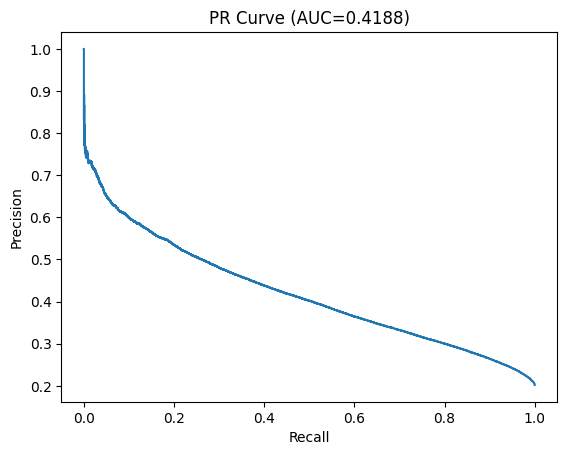

In [19]:
# 2) PR-AUC
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

y_prob = final_cpu.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

p, r, _ = precision_recall_curve(y_test, y_prob)
plt.plot(r, p)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"PR Curve (AUC={pr_auc:.4f})")
plt.show()


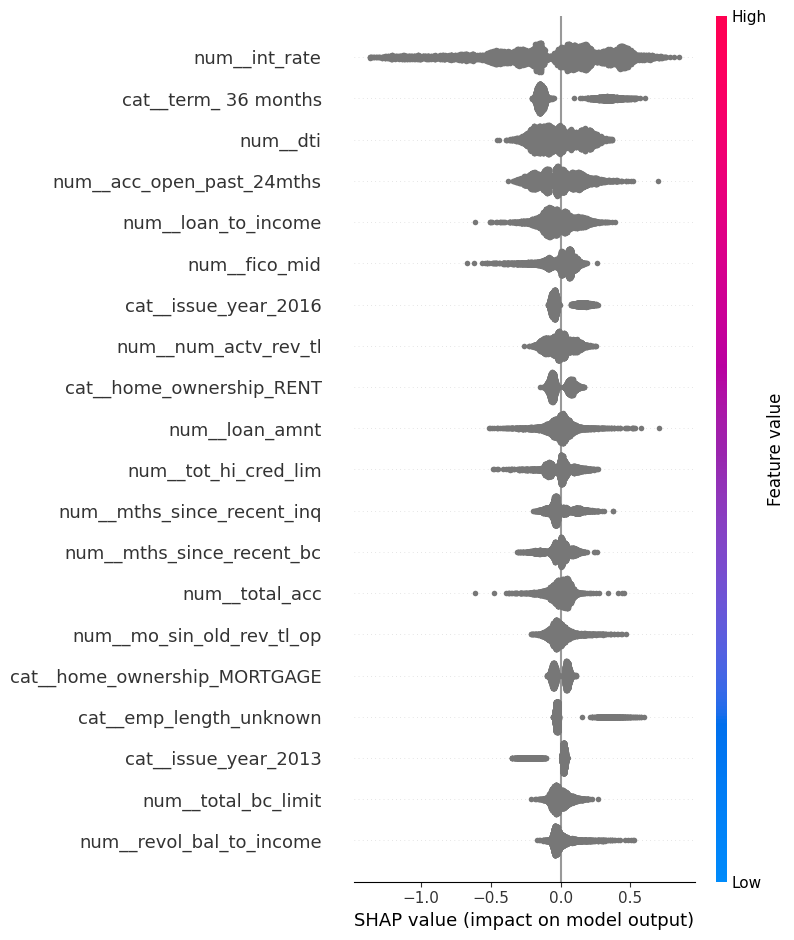

                         feature  shap_importance
0                  num__int_rate         0.356129
1           cat__term_ 36 months         0.193045
2                       num__dti         0.132591
3      num__acc_open_past_24mths         0.124753
4            num__loan_to_income         0.095210
5                  num__fico_mid         0.081965
6           cat__issue_year_2016         0.074974
7           num__num_actv_rev_tl         0.071400
8       cat__home_ownership_RENT         0.069631
9                 num__loan_amnt         0.067543
10          num__tot_hi_cred_lim         0.065805
11    num__mths_since_recent_inq         0.065330
12     num__mths_since_recent_bc         0.053928
13                num__total_acc         0.052490
14     num__mo_sin_old_rev_tl_op         0.051625
15  cat__home_ownership_MORTGAGE         0.050757
16       cat__emp_length_unknown         0.046607
17          cat__issue_year_2013         0.045720
18           num__total_bc_limit         0.045063


In [65]:
# 3) SHAP (트리 모델) + shap_rank 출력
import shap
import numpy as np
import pandas as pd

Xtr_t = final_cpu.named_steps["preprocess"].transform(X_train)
Xte_t = final_cpu.named_steps["preprocess"].transform(X_test)

explainer = shap.TreeExplainer(final_cpu.named_steps["model"])
shap_values = explainer.shap_values(Xte_t[:5000])  # 샘플링

# 그래프
shap.summary_plot(shap_values, Xte_t[:5000], feature_names=feat_names)

# 순위 테이블 (mean |SHAP|)
shap_importance = np.abs(shap_values).mean(axis=0)
shap_rank = (
    pd.DataFrame({
        "feature": feat_names,
        "shap_importance": shap_importance
    })
    .sort_values("shap_importance", ascending=False)
    .reset_index(drop=True)
)

print(shap_rank.head(30))


# SMOTENC 적용


In [23]:
# 필요 시 설치
# uv add imbalanced-learn

import pandas as pd
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, average_precision_score

# 1) 범주형 컬럼 인덱스 (SMOTENC용)
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

# 2) SMOTENC (train만)
smote_nc = SMOTENC(
    categorical_features=cat_idx,
    random_state=42,
    k_neighbors=5
)

X_train_sm, y_train_sm = smote_nc.fit_resample(X_train, y_train)

# fit_resample 결과가 ndarray일 수 있어서 컬럼 복원
if not isinstance(X_train_sm, pd.DataFrame):
    X_train_sm = pd.DataFrame(X_train_sm, columns=X_train.columns)

print("Before:", y_train.value_counts(normalize=True))
print("After :", pd.Series(y_train_sm).value_counts(normalize=True))

# 3) 기존 preprocessor 그대로 사용 + XGB 재학습
#    (SMOTE 적용했으니 scale_pos_weight는 1로)
xgb_smote = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
        device="cpu",
        n_jobs=-1,
        scale_pos_weight=1,
        colsample_bytree=0.8,
        learning_rate=0.1,
        max_depth=5,
        n_estimators=600,
        subsample=0.8
    ))
])

xgb_smote.fit(X_train_sm, y_train_sm)

# 4) 평가
y_pred = xgb_smote.predict(X_test)
y_prob = xgb_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_prob))


Before: target
0.0    0.797877
1.0    0.202123
Name: proportion, dtype: float64
After : target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64
              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    203905
         1.0       0.57      0.12      0.20     51655

    accuracy                           0.80    255560
   macro avg       0.69      0.55      0.55    255560
weighted avg       0.76      0.80      0.75    255560

PR-AUC: 0.4130780748498224


In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# smote 적용 모델: xgb_smote (이미 fit 완료 가정)
y_prob = xgb_smote.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)
rows = []

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)
    rows.append({
        "threshold": th,
        "precision_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_1": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    })

res = pd.DataFrame(rows).sort_values("f1_1", ascending=False)
print(res.head(10))

best_th = float(res.iloc[0]["threshold"])
y_pred_best = (y_prob >= best_th).astype(int)

print("best threshold:", best_th)
print(classification_report(y_test, y_pred_best))


    threshold  precision_1  recall_1      f1_1
12       0.22     0.348376  0.645765  0.452590
14       0.24     0.364370  0.594095  0.451703
13       0.23     0.355739  0.618527  0.451692
11       0.21     0.340307  0.670777  0.451535
15       0.25     0.372738  0.569761  0.450656
10       0.20     0.332095  0.695693  0.449579
16       0.26     0.381059  0.546104  0.448891
9        0.19     0.324141  0.721324  0.447285
17       0.27     0.389463  0.521905  0.446060
8        0.18     0.316019  0.747769  0.444278
best threshold: 0.21999999999999995
              precision    recall  f1-score   support

         0.0       0.89      0.69      0.78    203905
         1.0       0.35      0.65      0.45     51655

    accuracy                           0.68    255560
   macro avg       0.62      0.67      0.62    255560
weighted avg       0.78      0.68      0.71    255560



In [69]:
# 1) 일반 변수 중요도
import pandas as pd

feat_names = xgb_smote.named_steps["preprocess"].get_feature_names_out()
importances = xgb_smote.named_steps["model"].feature_importances_

fi_df_smote = (
    pd.DataFrame({"feature": feat_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

print(fi_df_smote.head(30))


                                   feature  importance
4                             num__pub_rec    0.165067
16               num__acc_open_past_24mths    0.039809
47                       cat__sub_grade_C3    0.033067
11                     num__num_actv_bc_tl    0.029599
45                       cat__sub_grade_C1    0.028196
26           num__mths_since_recent_bc_dlq    0.028017
106               cat__home_ownership_RENT    0.025560
24        num__mths_since_last_major_derog    0.025490
13                num__num_rev_tl_bal_gt_0    0.025453
72         cat__purpose_debt_consolidation    0.025062
49                       cat__sub_grade_C5    0.024935
87                    cat__issue_year_2015    0.024373
25     num__mths_since_recent_revol_delinq    0.024368
23             num__mths_since_last_delinq    0.023467
33                    cat__term_ 36 months    0.020968
1                            num__int_rate    0.020929
110                    cat__issue_month_12    0.020396
88        

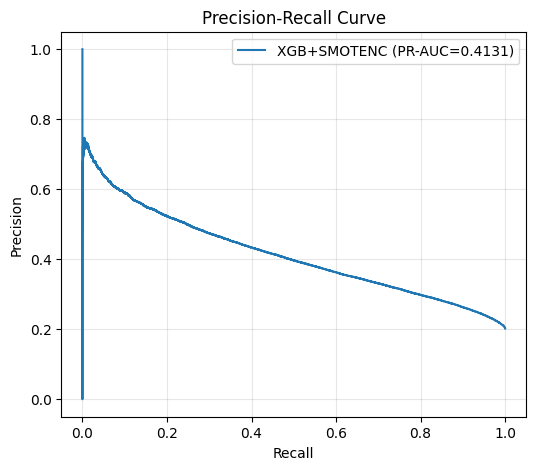

PR-AUC (SMOTENC): 0.4130780748498224


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# SMOTENC 모델
y_prob_sm = xgb_smote.predict_proba(X_test)[:, 1]
precision_sm, recall_sm, _ = precision_recall_curve(y_test, y_prob_sm)
pr_auc_sm = average_precision_score(y_test, y_prob_sm)

plt.figure(figsize=(6, 5))
plt.plot(recall_sm, precision_sm, label=f"XGB+SMOTENC (PR-AUC={pr_auc_sm:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("PR-AUC (SMOTENC):", pr_auc_sm)


                             feature  shap_importance
0                      num__int_rate         0.542263
1            num__mths_since_rcnt_il         0.269154
2          num__acc_open_past_24mths         0.252682
3                       num__pub_rec         0.248485
4               cat__term_ 36 months         0.208326
5               cat__issue_year_2015         0.156665
6         num__mths_since_recent_inq         0.132602
7                           num__dti         0.125464
8           cat__home_ownership_RENT         0.116544
9                num__num_actv_bc_tl         0.116046
10               num__loan_to_income         0.115464
11       num__mths_since_last_delinq         0.087616
12              num__tot_hi_cred_lim         0.079759
13              cat__issue_year_2016         0.079004
14                     num__fico_mid         0.078745
15          num__num_rev_tl_bal_gt_0         0.076800
16              num__num_actv_rev_tl         0.064890
17         num__mths_since_r

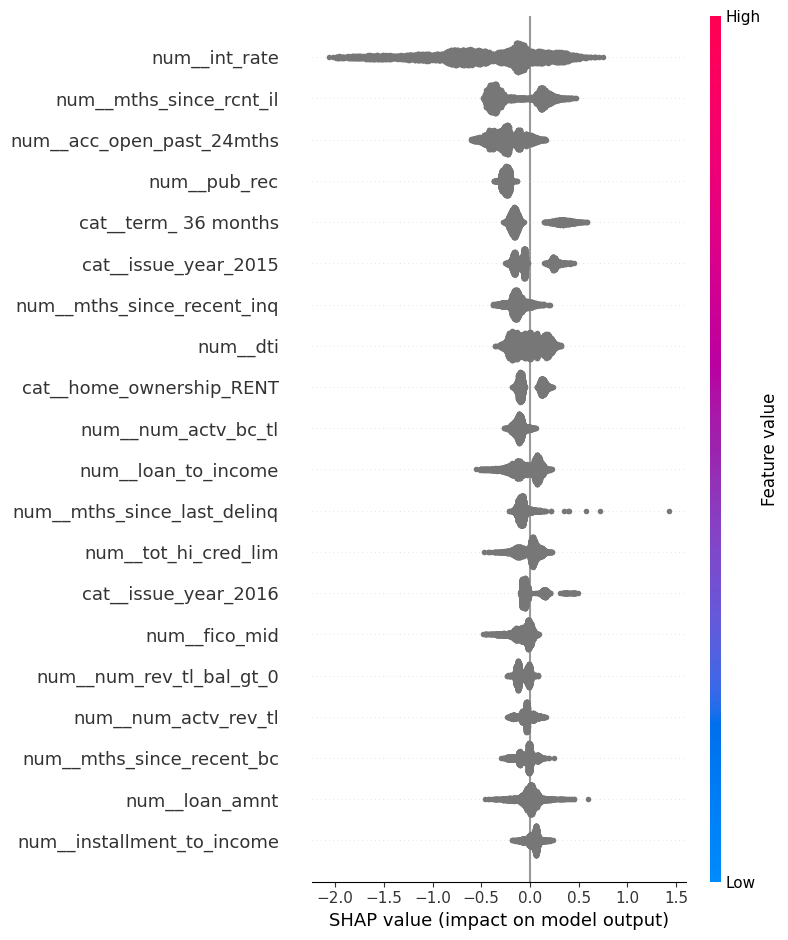

In [68]:
import numpy as np
import pandas as pd
import shap

# xgb_smote: Pipeline(preprocess + XGBClassifier) 이미 fit 완료 가정
X_sm = xgb_smote.named_steps["preprocess"].transform(X_test)[:5000]
feat_sm = xgb_smote.named_steps["preprocess"].get_feature_names_out()

explainer_sm = shap.TreeExplainer(xgb_smote.named_steps["model"])
sv_sm = explainer_sm.shap_values(X_sm)

# 1) SHAP 중요도 테이블
shap_rank_sm = (
    pd.DataFrame({
        "feature": feat_sm,
        "shap_importance": np.abs(sv_sm).mean(axis=0)
    })
    .sort_values("shap_importance", ascending=False)
    .reset_index(drop=True)
)

print(shap_rank_sm.head(30))

# 2) SHAP plot (sparse 기준으로 일관성 유지)
shap.summary_plot(sv_sm, X_sm, feature_names=feat_sm)



In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, average_precision_score
)

def eval_model_with_best_threshold(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:, 1]

    # PR-AUC (threshold와 무관)
    pr_auc = average_precision_score(y_test, y_prob)

    # threshold sweep
    thresholds = np.arange(0.1, 0.91, 0.01)
    rows = []
    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        rows.append({
            "threshold": th,
            "precision_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            "recall_1": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            "f1_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        })

    th_df = pd.DataFrame(rows).sort_values("f1_1", ascending=False)
    best_th = float(th_df.iloc[0]["threshold"])
    y_pred_best = (y_prob >= best_th).astype(int)

    print(f"\n===== {name} =====")
    print(f"PR-AUC: {pr_auc:.6f}")
    print(f"Best threshold: {best_th:.2f}")
    print(classification_report(y_test, y_pred_best))

    return {
        "model": name,
        "best_threshold": best_th,
        "f1_1": float(th_df.iloc[0]["f1_1"]),
        "precision_1": float(th_df.iloc[0]["precision_1"]),
        "recall_1": float(th_df.iloc[0]["recall_1"]),
        "pr_auc": float(pr_auc),
    }

# 1) class weight + threshold 최적화 모델
res_weighted = eval_model_with_best_threshold(
    final_cpu, X_test, y_test, "XGB + class weight"
)

# 2) SMOTE + threshold 최적화 모델
res_smote = eval_model_with_best_threshold(
    xgb_smote, X_test, y_test, "XGB + SMOTENC"
)

# 비교표
compare_df = pd.DataFrame([res_weighted, res_smote]).sort_values("f1_1", ascending=False)
print("\n=== Summary Comparison ===")
print(compare_df)



===== XGB + class weight =====
PR-AUC: 0.418842
Best threshold: 0.54
              precision    recall  f1-score   support

         0.0       0.88      0.73      0.80    203905
         1.0       0.36      0.61      0.45     51655

    accuracy                           0.70    255560
   macro avg       0.62      0.67      0.63    255560
weighted avg       0.78      0.70      0.73    255560


===== XGB + SMOTENC =====
PR-AUC: 0.413078
Best threshold: 0.22
              precision    recall  f1-score   support

         0.0       0.89      0.69      0.78    203905
         1.0       0.35      0.65      0.45     51655

    accuracy                           0.68    255560
   macro avg       0.62      0.67      0.62    255560
weighted avg       0.78      0.68      0.71    255560


=== Summary Comparison ===
                model  best_threshold      f1_1  precision_1  recall_1  \
0  XGB + class weight            0.54  0.454133     0.361924  0.609389   
1       XGB + SMOTENC            0.

# 일단 지표 + 변수중요도 + shap 변수중요도 + pr-auc까지 뽑음
